# 1. Import 

In [2]:
from sklearn.decomposition import PCA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

In [3]:
clr_df = pd.read_csv("../data/processed/06_clr_healthy_data.csv")


# 2. Batch effect

Empirical Bayes methods have proven:
- handle high-dimensional data robustly with small sample sizes
There are also other methods mentioned in the paper. However, the EB method has shown best resulsts and is used until today. It looks across all the samples, not only one, and adjusts the batch effect based on all.

*We also filter out the genes called as “absent” in more than 80% samples to eliminate noise.*

In [4]:
absent_proportion = (clr_df == 0).mean(axis=0)

taxa_to_remove = absent_proportion[absent_proportion > 0.80]
taxa_to_keep = absent_proportion[absent_proportion <= 0.80]

print(f"Total taxa: {clr_df.shape[1]}")
print(f"Taxa absent in >80% of samples: {len(taxa_to_remove)}")
print(f"Taxa remaining after filter: {len(taxa_to_keep)}")


Total taxa: 609
Taxa absent in >80% of samples: 0
Taxa remaining after filter: 609


$$Y_{ijg} = \alpha_{g} + X\beta_{g} + \gamma_{ig} + \delta_{ig}\epsilon_{ijg}$$


* **$Y_{ijg}$** (The Result): The actual measured value for a gene in your data.
* **$\alpha_{g}$** (The Baseline): The normal, starting expression level of the gene.
* **$X\beta_{g}$** (The Biology): The real change caused by your experiment (e.g., drug effect).
* **$\gamma_{ig}$** (The Shift): **Additive noise** that moves all data in a batch up or down.
* **$\delta_{ig}$** (The Volume): **Multiplicative noise** that makes data in a batch more or less "spread out."
* **$\epsilon_{ijg}$** (The Error): Small, random "hiss" or vibration found in every measurement.

### Steps from EB-method


1. Standardizing data, so all samples have similar mean and variance
$$Z_{ijg} = \frac{Y_{ijg} - \hat{\alpha}_{g} - X\hat{\beta}_{g}}{\hat{\sigma}_{g}}$$


2. Estimate Batch effect
- Additive effects: Shift the expression levels up or down
$$Y_{ijg} = \alpha_{g} + X\beta_{g} + \gamma_{ig} + \delta_{ig}\epsilon_{ijg}$$
- Multiplicative effects: Change spread of the data. Bayes part involves using shrinkage. If a sample has outlier results, the method shrinks the result back toward the average of all other genes
$$\delta_{ig}^{2*} = \frac{\theta_{i} + \frac{1}{2} \sum_{j} (Z_{ijg} - \gamma_{ig}^*)^2}{\lambda_{i} + \frac{n_{i}}{2} - 1}$$

3. Adjusting Data: Method takes stable batch effect estimates and applies them to the original data
$$Y_{ijg}^* = \frac{\hat{\sigma}_{g}}{\delta_{ig}^*}(Z_{ijg} - \gamma_{ig}^*) + \hat{\alpha}_{g} + X\hat{\beta}_{g}$$


* **$Y_{ijg}^*$** (Adjusted Result): The clean, final data point with batch effects removed.
* **$\hat{\sigma}_{g}$** (Biological Standard Deviation): The "natural" variation of the gene we want to keep.
* **$\delta_{ig}^*$** (Batch Scale): The estimated "volume" or noise spread of the specific batch.
* **$Z_{ijg}$** (Standardized Data): The "leveled" data from Step 1.
* **$\gamma_{ig}^*$** (Batch Shift): The estimated "additive" shift (up or down) of the specific batch.
* **$\hat{\alpha}_{g}$** (Baseline): The gene's average starting expression level.
* **$X\hat{\beta}_{g}$** (Biological Signal): The real experimental effect (e.g., treatment effect) we want to preserve.





### Difficulties

The problem in this PA is, that the interest lies in the country differences, which are also "batch differences". This makes it difficult to correct the batch effect without losing valuable informations. 

If done PCA: Clusters could explain real biological differences between countries OR technical differences

## 2.1 PCA

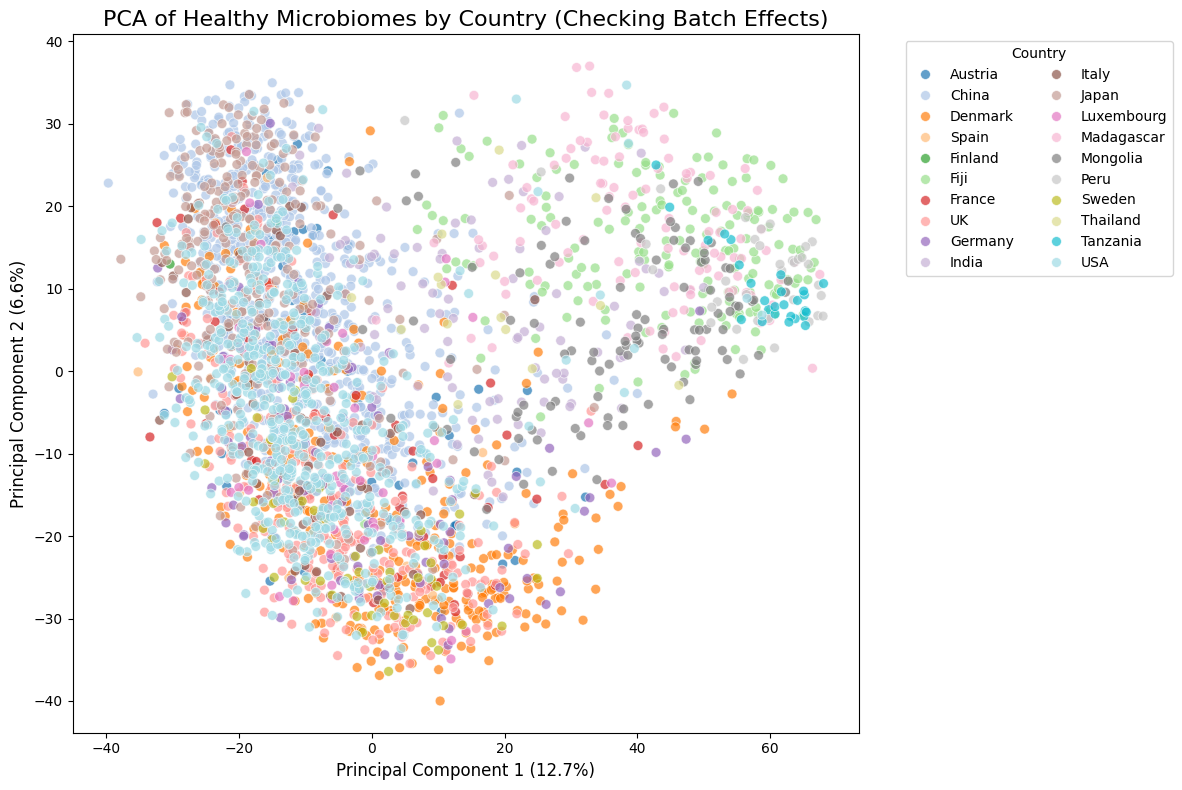

In [5]:
# --- 2. Separate Features (Microbiome) and Labels (Country) ---
# Automatically find all the microbiome columns (they all start with "msp_")
microbiome_cols = [col for col in clr_df.columns if col.startswith('msp_')]


X = clr_df[microbiome_cols]
y = clr_df['Geography']

# Run PCA 
pca = PCA(n_components=2)
principal_components = pca.fit_transform(X)

# Create a new DataFrame specifically for plotting
pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])
pca_df['Country'] = y.values

# Calculate how much variance is explained by the first two components
explained_variance = pca.explained_variance_ratio_ * 100

# --- 4. Plot the Results ---
plt.figure(figsize=(12, 8))

# Scatter plot coloring the dots by Country
sns.scatterplot(
    x='PC1', 
    y='PC2', 
    hue='Country', 
    palette='tab20', # 'tab20' handles up to 20 colors. 
    data=pca_df, 
    alpha=0.7,       # slight transparency
    s=50             # dot size
)

# Add titles and labels
plt.title('PCA of Healthy Microbiomes by Country (Checking Batch Effects)', fontsize=16)
plt.xlabel(f'Principal Component 1 ({explained_variance[0]:.1f}%)', fontsize=12)
plt.ylabel(f'Principal Component 2 ({explained_variance[1]:.1f}%)', fontsize=12)

# Move the legend outside the plot so it doesn't cover your dots
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Country', ncol=2)
plt.tight_layout()

# Show the plot
plt.show()

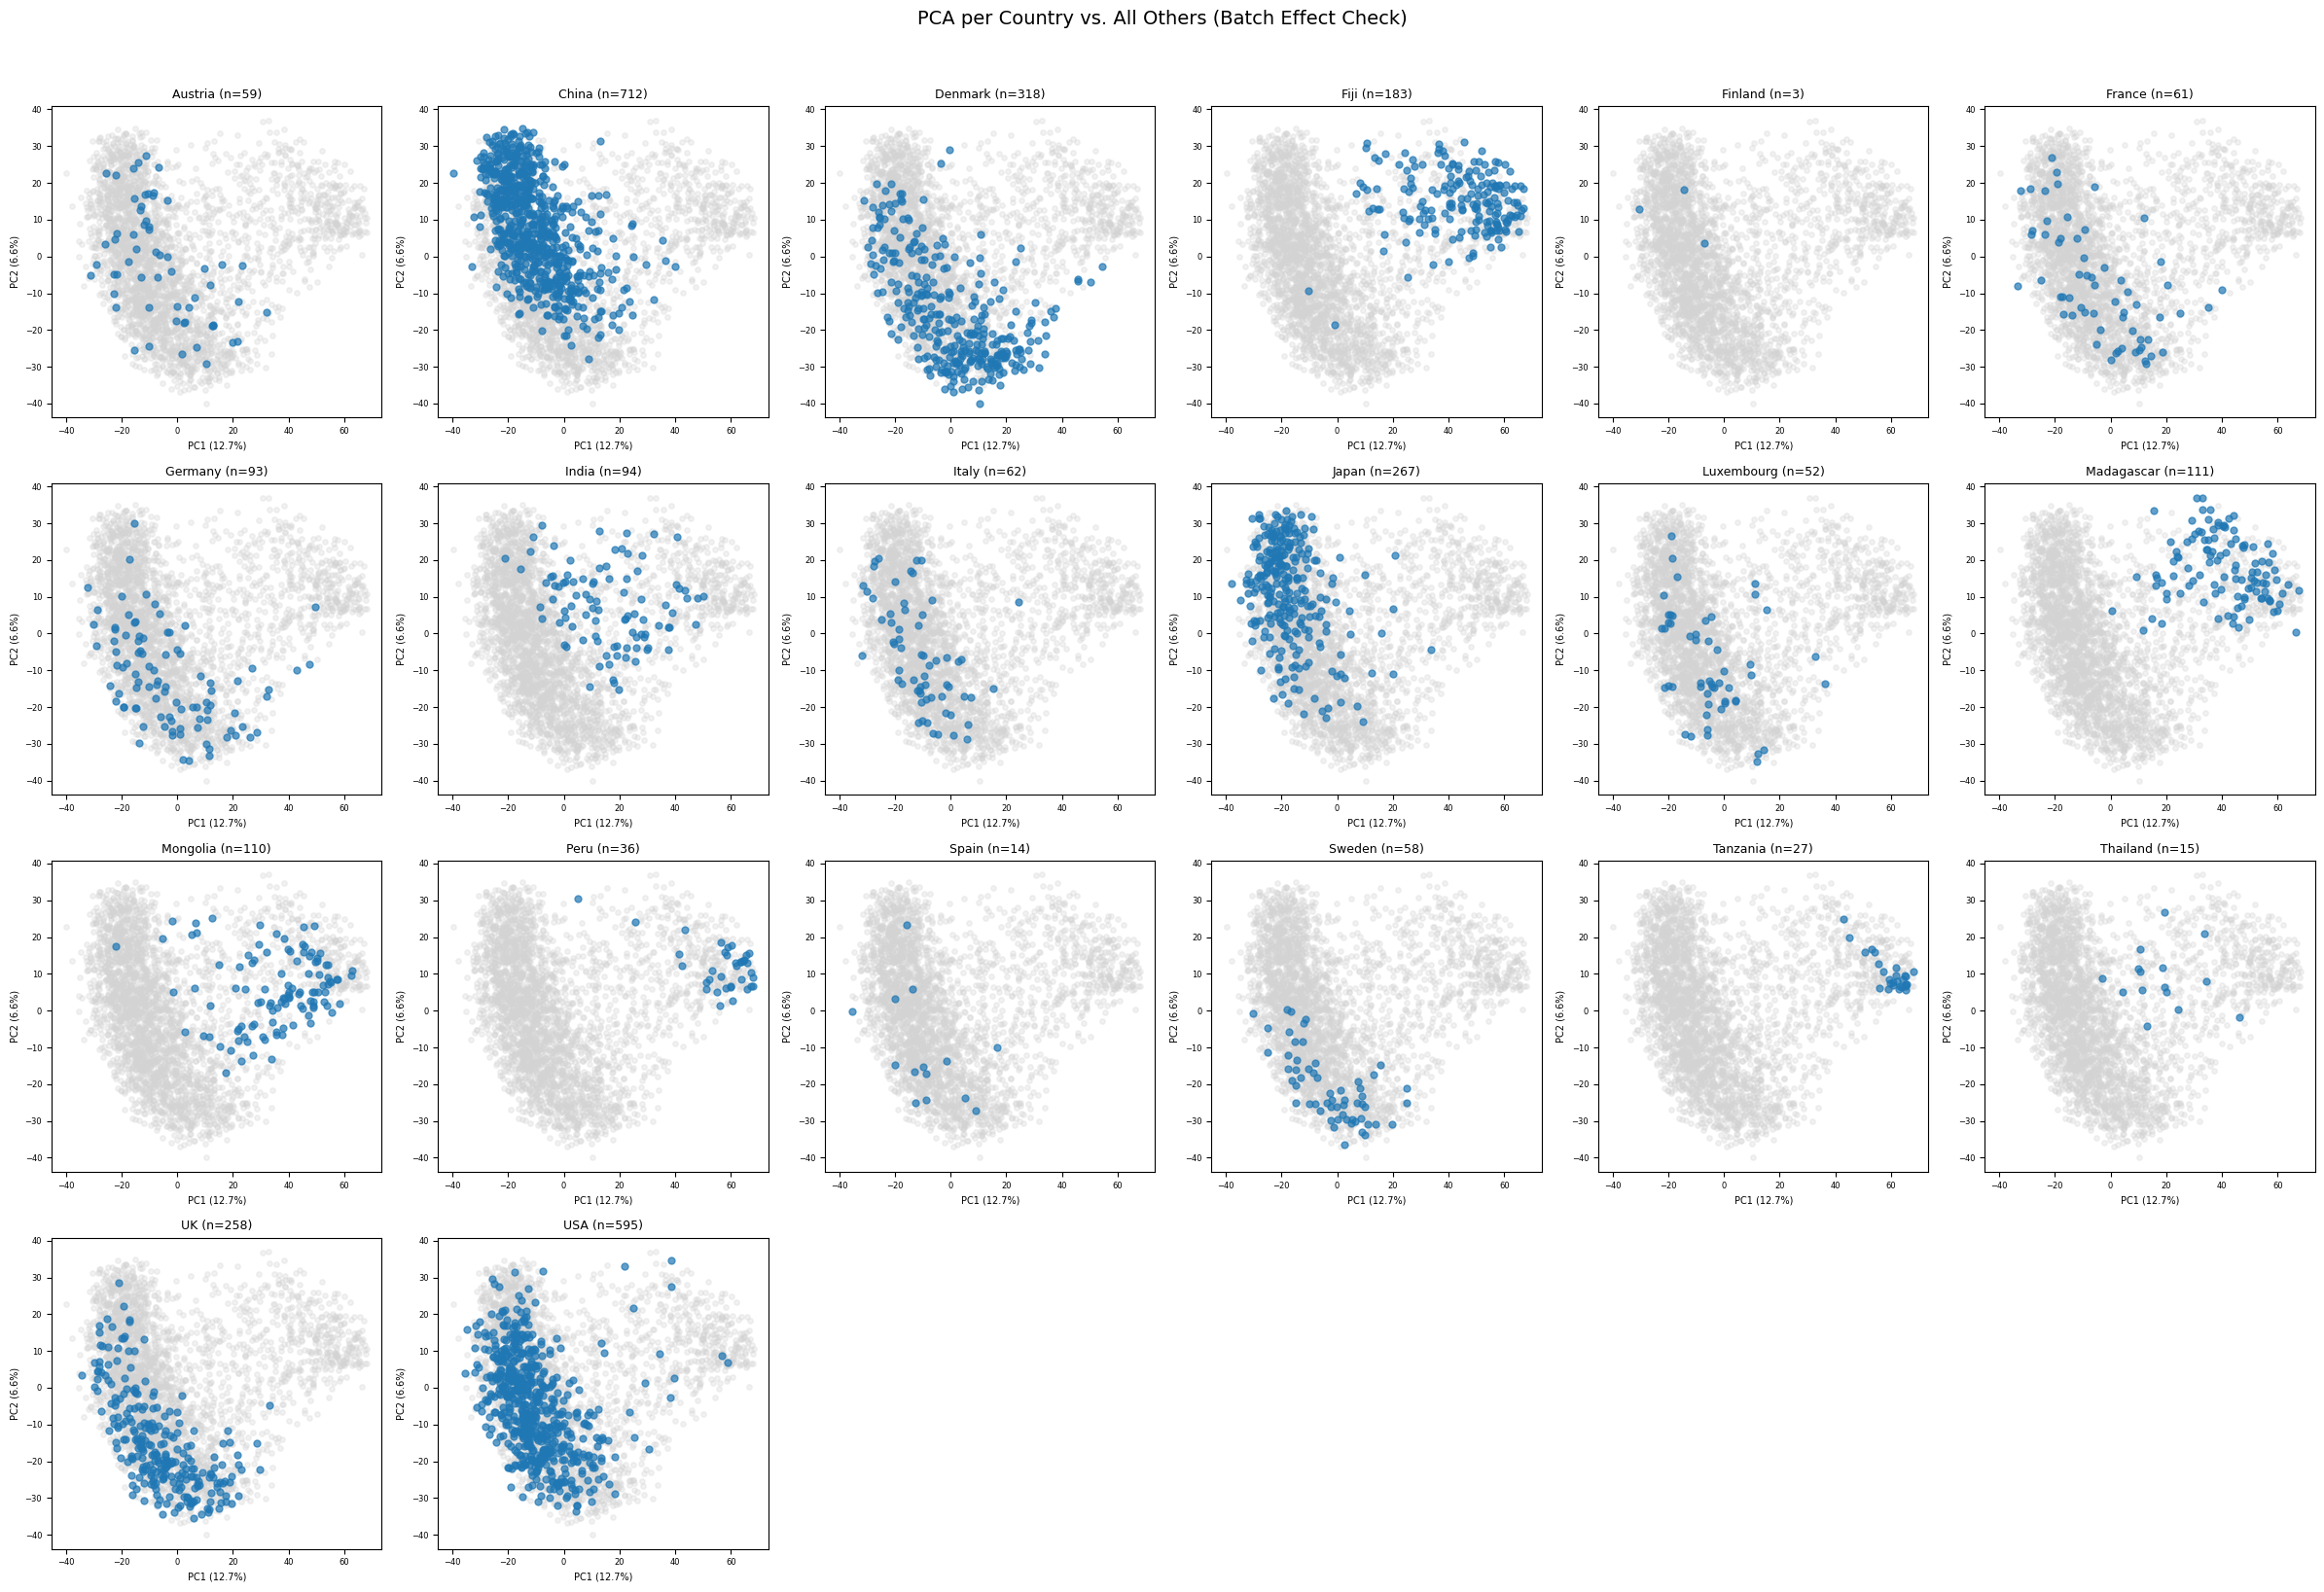

In [6]:
# --- PCA per Country ---
countries = pca_df['Country'].unique()
n_countries = len(countries)

# Calculate grid size
n_cols = 6
n_rows = math.ceil(n_countries / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 4))
axes = axes.flatten()

for i, country in enumerate(sorted(countries)):
    ax = axes[i]
    
    # All other countries as grey background for reference
    other = pca_df[pca_df['Country'] != country]
    ax.scatter(other['PC1'], other['PC2'], c='lightgrey', alpha=0.3, s=15, label='Other')
    
    # Highlight the current country
    subset = pca_df[pca_df['Country'] == country]
    ax.scatter(subset['PC1'], subset['PC2'], alpha=0.7, s=25, label=country)
    
    ax.set_title(f'{country} (n={len(subset)})', fontsize=9)
    ax.set_xlabel(f'PC1 ({explained_variance[0]:.1f}%)', fontsize=7)
    ax.set_ylabel(f'PC2 ({explained_variance[1]:.1f}%)', fontsize=7)
    ax.tick_params(labelsize=6)

# Hide any empty subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('PCA per Country vs. All Others (Batch Effect Check)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

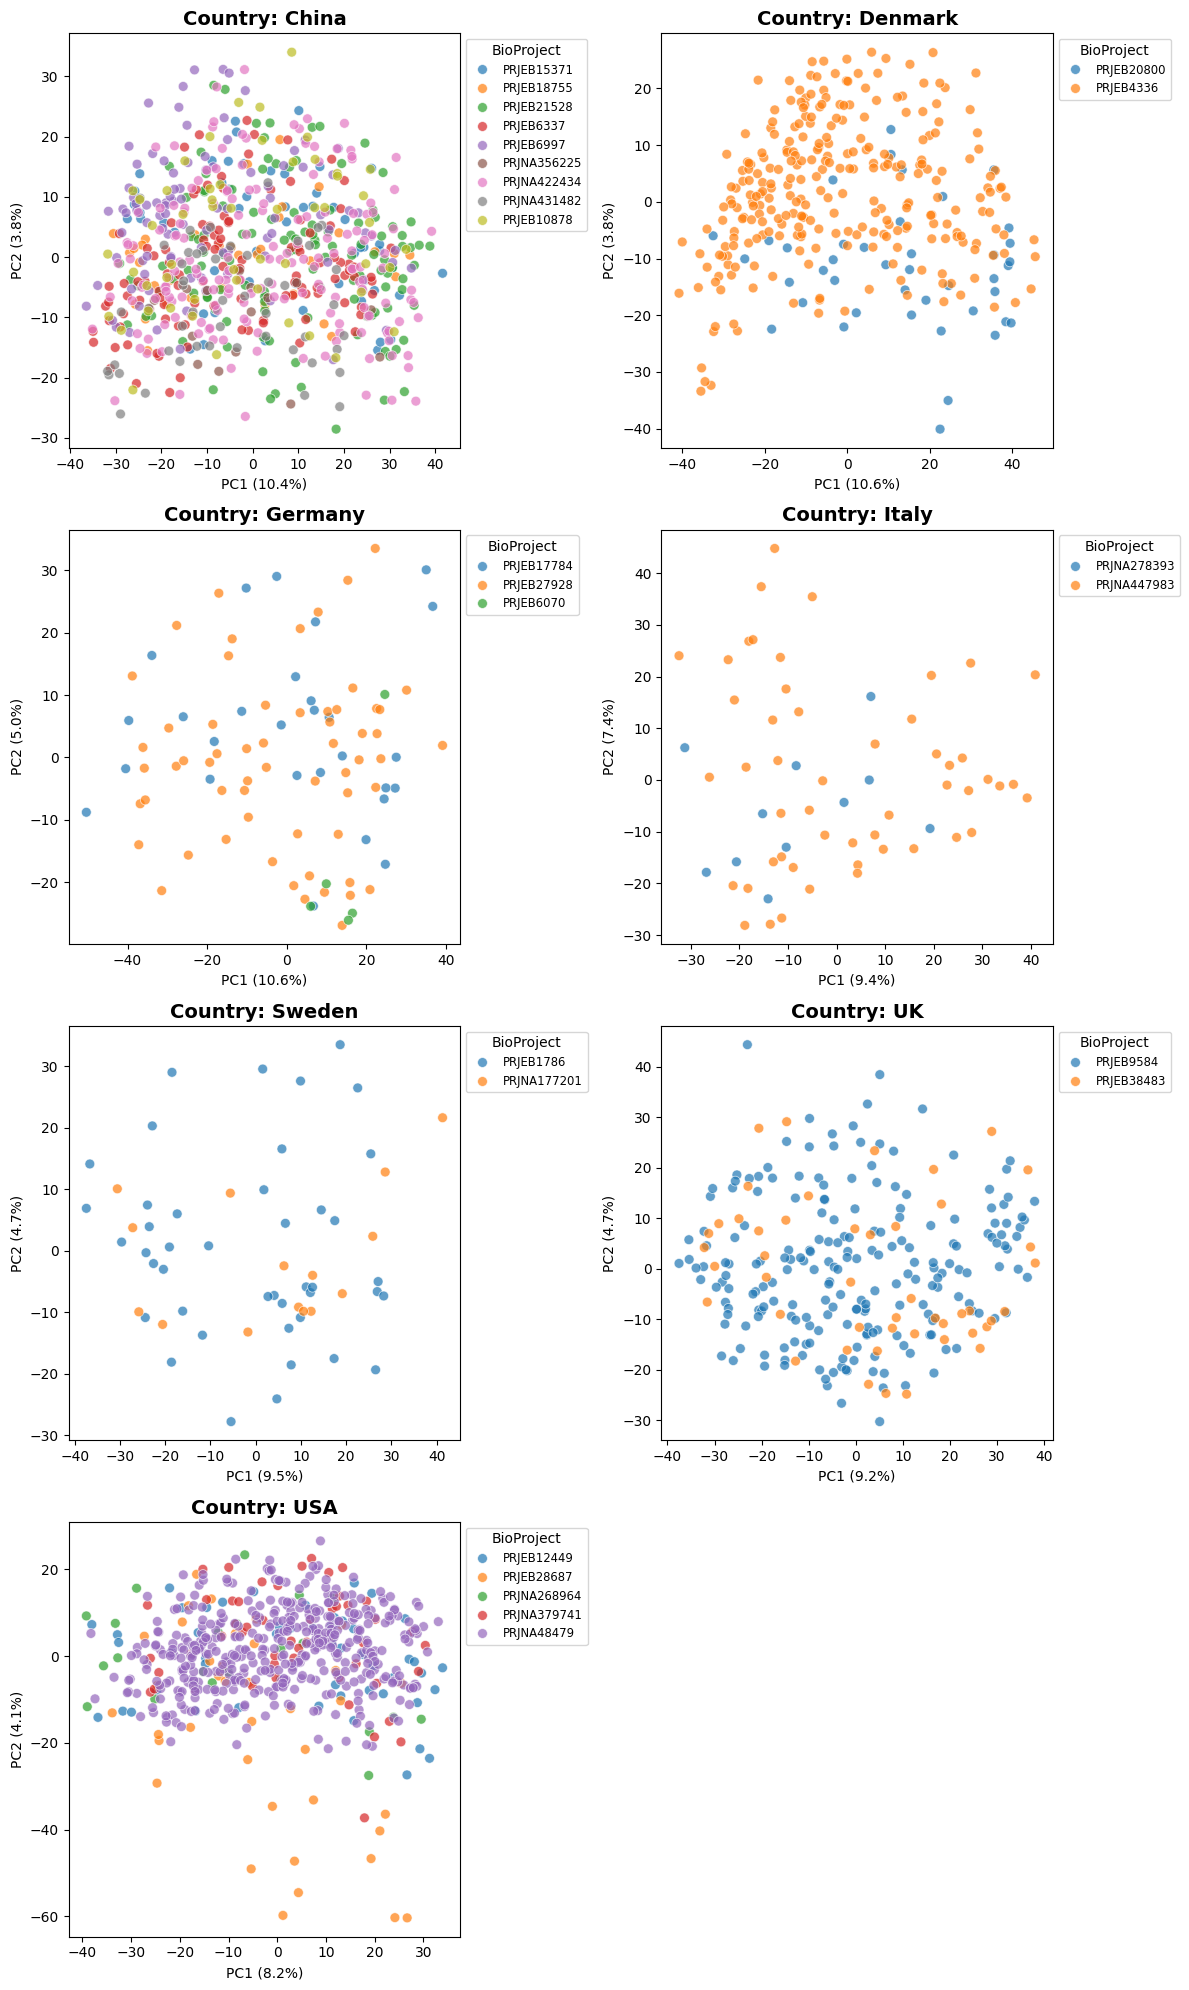

In [7]:
import math
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# --- 1. Load Data & Identify Multi-batch Countries ---
# (Assuming clr_df and microbiome_cols are already defined as per your snippet)
project_counts = clr_df.groupby('Geography')['BioProject'].nunique()
multi_batch_countries = project_counts[project_counts > 1].index.tolist()

if not multi_batch_countries:
    print("No countries have multiple BioProjects.")
else:
    # --- 2. Set up the Grid Dimensions ---
    num_plots = len(multi_batch_countries)
    cols = 2  # Set to 2 or 3 depending on how wide you want the grid in Word
    rows = math.ceil(num_plots / cols)

    # Create the figure
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 6, rows * 5))
    axes = axes.flatten()  # Flatten in case of 2D array to iterate easily

    # --- 3. Loop and Plot ---
    for i, country in enumerate(multi_batch_countries):
        # Data Processing
        country_df = clr_df[clr_df['Geography'] == country]
        X_country = country_df[microbiome_cols]
        
        pca = PCA(n_components=2)
        pcs = pca.fit_transform(X_country)
        var = pca.explained_variance_ratio_ * 100
        
        plot_df = pd.DataFrame(pcs, columns=['PC1', 'PC2'])
        plot_df['BioProject'] = country_df['BioProject'].values
        
        # Plotting on the specific subplot axis
        ax = axes[i]
        sns.scatterplot(
            data=plot_df, x='PC1', y='PC2', 
            hue='BioProject', palette='tab10', 
            s=50, alpha=0.7, ax=ax
        )
        
        ax.set_title(f"Country: {country}", fontsize=14, fontweight='bold')
        ax.set_xlabel(f"PC1 ({var[0]:.1f}%)")
        ax.set_ylabel(f"PC2 ({var[1]:.1f}%)")
        ax.legend(title='BioProject', bbox_to_anchor=(1, 1), loc='upper left', fontsize='small')

    # --- 4. Clean up Empty Subplots ---
    # If the grid is 2x2 but you only have 3 plots, remove the 4th empty axis
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    
    # Save for Word: DPI 300 ensures it doesn't look blurry when resized
    plt.show()

## 3. Validation of Library Size Independence

While the CLR transformation is a robust tool for handling compositionality, it can remain sensitive to library size. The total sum of bacterial counts (sampling effort) per sample. Especially in sparse datasets. If this technical factor is not addressed, the most significant patterns in the data may reflect sequencing depth rather than true biology, potentially leading to Type 1 Errors (False Positives) when comparing cohorts. [Dennis E. te Beest et al. 2021)](../Papers/Preprocessing/DennisEteBeest2021.pdf)


### Validation Steps

Due to this, we performed a Log-Ratio PCA diagnostic:

- **Metric:** We calculated the correlation (Pearson's R) between the log₁₀-transformed library sizes and the first principal component (PC1).
- **Success Criterion:** A low correlation and a non-linear "cloud" distribution in the diagnostic plot confirm that the biological signal is successfully decoupled from sequencing depth.

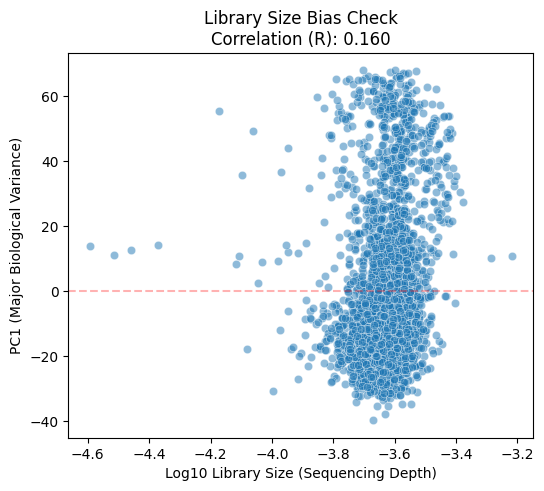

Explained Variance of PC1: 12.7%


In [8]:
filtered_data = pd.read_csv("../data/processed/04_filtered_healthy_data.csv")

# 1. Run PCA on your CLR data
pca = PCA(n_components=2)
pcs = pca.fit_transform(clr_df[microbiome_cols])

# 2. Get Log-Library Size (RAW counts table here!)
log_lib_size = np.log10(filtered_data[microbiome_cols].sum(axis=1))
# 3. Calculate Correlation (The "te Beest" Metric)
correlation = np.corrcoef(log_lib_size, pcs[:, 0])[0, 1]

# 4. Diagnostic Plot
plt.figure(figsize=(6, 5))
sns.scatterplot(x=log_lib_size, y=pcs[:, 0], alpha=0.5)
plt.title(f"Library Size Bias Check\nCorrelation (R): {correlation:.3f}")
plt.xlabel("Log10 Library Size (Sequencing Depth)")
plt.ylabel("PC1 (Major Biological Variance)")
plt.axhline(0, color='red', linestyle='--', alpha=0.3)
plt.show()

print(f"Explained Variance of PC1: {pca.explained_variance_ratio_[0]*100:.1f}%")